In [29]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Predicting Freight Cost

**Objective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.
- Freight is a non-trivial component of landed cost.
- Poor freight estimates distort margin and inventory planning.
- Automating freiht estimation helps procurrement terms forecast true cost before invoice arrival.


In [2]:
conn=sqlite3.connect("../Data/inventory.db")
tables= pd.read_sql_query("select name from sqlite_master where type= 'table'",conn)


In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
# similar command as df.head for viewing dta using db
for table in tables['name']:
    print("Table name", table)
    df=pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


**so the vendor invoice table is the main table we will work on for predicting freight cost as it contain the freight values along with quantity and dollars(price)**, we will extract this table.

In [5]:
vendor_df=pd.read_sql_query(" select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [6]:
vendor_df.shape

(5543, 10)

In [7]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0
std,34582.0,1601.0,14453.0,140234.0,714.0
min,2.0,8106.0,1.0,4.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0
50%,7240.0,10890.0,423.0,4765.0,25.0
75%,10754.0,12276.0,5100.0,44587.0,230.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0


Finding the corelation between freight, quantity, dollars, as it is the regression model we using to predict freight.

In [8]:
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


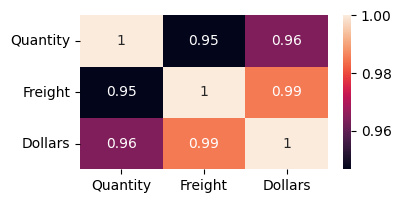

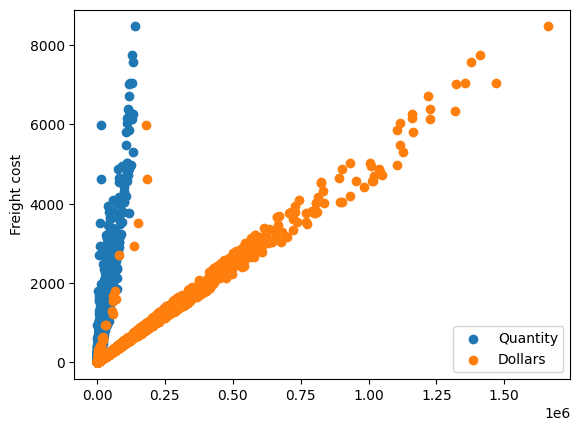

In [9]:
# Relationship between Quantity, Freight, Dollars

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', 'Freight', 'Dollars']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'])
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'])
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight cost')
plt.show()

In [10]:
vendor_df['freight_per_unit']=vendor_df['Freight']/vendor_df['Quantity']

In [11]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


In [12]:
low_quantity= vendor_df['Quantity'].quantile(0.25)
high_quantity=vendor_df['Quantity'].quantile(0.75)

In [13]:
high_quantity

np.float64(5100.5)

In [14]:
low_quantity

np.float64(83.0)

In [15]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit'].mean()    #values in low quantity

np.float64(0.09489854253138316)

In [16]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_per_unit'].mean()

np.float64(0.049077654690759046)

By above eda we got to know that the freight cost is minimum when ordered in bulk as compared to when ordered in less amount, total difference of 0.05 

# Model building

In [17]:
x= vendor_df[['Quantity','Dollars']]
y=vendor_df['Freight']

In [18]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
X_train.shape, X_test.shape

((4434, 2), (1109, 2))

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
model1= LinearRegression()
model1.fit(X_train,y_train)

model2=DecisionTreeRegressor(max_depth=4,random_state=42)
model2.fit(X_train,y_train)

model3=RandomForestRegressor(max_depth=4,random_state=42)
model3.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
def evaluate_model(model,X_test,y_test,model_name):
    preds=model.predict(X_test)

    mae=mean_absolute_error(y_test,preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2=r2_score(y_test,preds)*100

    print(f"\n{model_name} Performance: ")
    print(f" MAE :{mae:.2f}")
    print(f"RMSE :{rmse:.2f}")
    print(f"R2  :{r2:.2f}%")

In [31]:
evaluate_model(model1,X_test,y_test, 'LinearRegression')
evaluate_model(model2,X_test,y_test, 'Decision Tree Regressor')
evaluate_model(model3,X_test,y_test, 'Random Forest Regressor')


LinearRegression Performance: 
 MAE :24.46
RMSE :124.43
R2  :97.00%

Decision Tree Regressor Performance: 
 MAE :38.12
RMSE :138.25
R2  :96.30%

Random Forest Regressor Performance: 
 MAE :30.27
RMSE :130.63
R2  :96.70%


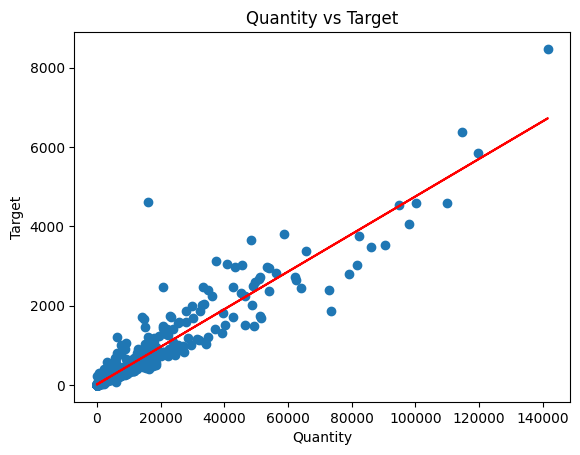

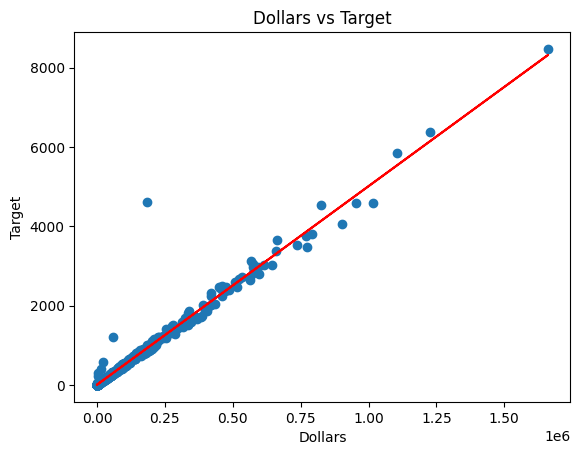

In [37]:
# Predictions
predictions = model1.predict(X_test)

# First feature
plt.scatter(X_test.iloc[:, 0], y_test)
m1, b1 = np.polyfit(X_test.iloc[:, 0], y_test, 1) 
#np.polyfit() finds the equation of a polynomial that best fits your data.1=polynomial of degree1
plt.plot(X_test.iloc[:, 0], m1 * X_test.iloc[:, 0] + b1, color='red')
plt.xlabel('Quantity')
plt.ylabel('Target')
plt.title('Quantity vs Target')
plt.show()

# Second feature
plt.scatter(X_test.iloc[:, 1], y_test)
m2, b2 = np.polyfit(X_test.iloc[:, 1], y_test, 1)
plt.plot(X_test.iloc[:, 1], m2 * X_test.iloc[:, 1] + b2, color='red')
plt.xlabel('Dollars')
plt.ylabel('Target')
plt.title('Dollars vs Target')
plt.show()


In [43]:
input_data = {
    "Quantity": [100, 500, 1000, 2000],
    "Dollars": [1000, 5000, 10000, 20000]
}

new_orders = pd.DataFrame(input_data)

predictions = model1.predict(new_orders)

new_orders["Predicted Freight"] = predictions

print(new_orders)



   Quantity  Dollars  Predicted Freight
0       100     1000          10.619290
1       500     5000          30.676958
2      1000    10000          55.749044
3      2000    20000         105.893214
